**Chapter 6 – Decision Trees**

_This notebook contains all the sample code and solutions to the exercises in chapter 6._

<table align="left">
  <td>
    <a target="_blank" href="https://colab.research.google.com/github/ageron/handson-ml/blob/master/06_decision_trees.ipynb"><img src="https://www.tensorflow.org/images/colab_logo_32px.png" />Run in Google Colab</a>
  </td>
</table>

**Warning**: this is the code for the 1st edition of the book. Please visit https://github.com/ageron/handson-ml2 for the 2nd edition code, with up-to-date notebooks using the latest library versions.

# Setup

First, let's make sure this notebook works well in both python 2 and 3, import a few common modules, ensure MatplotLib plots figures inline and prepare a function to save the figures:

In [ ]:
# To support both python 2 and python 3
from __future__ import division, print_function, unicode_literals

# Common imports
import numpy as np
import os

# to make this notebook's output stable across runs
np.random.seed(42)

# To plot pretty figures
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

# Where to save the figures
PROJECT_ROOT_DIR = "."
CHAPTER_ID = "decision_trees"
IMAGES_PATH = os.path.join(PROJECT_ROOT_DIR, "images", CHAPTER_ID)
os.makedirs(IMAGES_PATH, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = os.path.join(IMAGES_PATH, fig_id + "." + fig_extension)
    print("Saving figure", fig_id)
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

# Training and visualizing

In [ ]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier

iris = load_iris()
X = iris.data[:, 2:] # petal length and width
y = iris.target

tree_clf = DecisionTreeClassifier(max_depth=2, random_state=42)
tree_clf.fit(X, y)

DecisionTreeClassifier(class_weight=None, criterion='gini', max_depth=2,
            max_features=None, max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, presort=False, random_state=42,
            splitter='best')

In [ ]:
from sklearn.tree import export_graphviz

def image_path(fig_id):
    return os.path.join(IMAGES_PATH, fig_id)

export_graphviz(
        tree_clf,
        out_file=image_path("iris_tree.dot"),
        feature_names=iris.feature_names[2:],
        class_names=iris.target_names,
        rounded=True,
        filled=True
    )

Saving figure decision_tree_decision_boundaries_plot


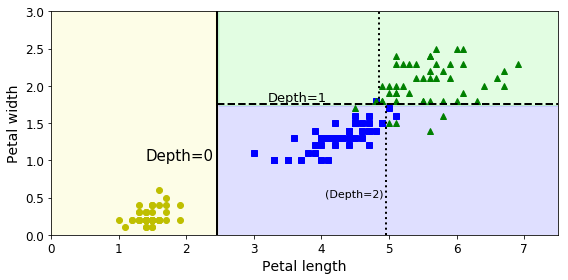

In [ ]:
from matplotlib.colors import ListedColormap

def plot_decision_boundary(clf, X, y, axes=[0, 7.5, 0, 3], iris=True, legend=False, plot_training=True):
    x1s = np.linspace(axes[0], axes[1], 100)
    x2s = np.linspace(axes[2], axes[3], 100)
    x1, x2 = np.meshgrid(x1s, x2s)
    X_new = np.c_[x1.ravel(), x2.ravel()]
    y_pred = clf.predict(X_new).reshape(x1.shape)
    custom_cmap = ListedColormap(['#fafab0','#9898ff','#a0faa0'])
    plt.contourf(x1, x2, y_pred, alpha=0.3, cmap=custom_cmap)
    if not iris:
        custom_cmap2 = ListedColormap(['#7d7d58','#4c4c7f','#507d50'])
        plt.contour(x1, x2, y_pred, cmap=custom_cmap2, alpha=0.8)
    if plot_training:
        plt.plot(X[:, 0][y==0], X[:, 1][y==0], "yo", label="Iris-Setosa")
        plt.plot(X[:, 0][y==1], X[:, 1][y==1], "bs", label="Iris-Versicolor")
        plt.plot(X[:, 0][y==2], X[:, 1][y==2], "g^", label="Iris-Virginica")
        plt.axis(axes)
    if iris:
        plt.xlabel("Petal length", fontsize=14)
        plt.ylabel("Petal width", fontsize=14)
    else:
        plt.xlabel(r"$x_1$", fontsize=18)
        plt.ylabel(r"$x_2$", fontsize=18, rotation=0)
    if legend:
        plt.legend(loc="lower right", fontsize=14)

plt.figure(figsize=(8, 4))
plot_decision_boundary(tree_clf, X, y)
plt.plot([2.45, 2.45], [0, 3], "k-", linewidth=2)
plt.plot([2.45, 7.5], [1.75, 1.75], "k--", linewidth=2)
plt.plot([4.95, 4.95], [0, 1.75], "k:", linewidth=2)
plt.plot([4.85, 4.85], [1.75, 3], "k:", linewidth=2)
plt.text(1.40, 1.0, "Depth=0", fontsize=15)
plt.text(3.2, 1.80, "Depth=1", fontsize=13)
plt.text(4.05, 0.5, "(Depth=2)", fontsize=11)

save_fig("decision_tree_decision_boundaries_plot")
plt.show()

# Predicting classes and class probabilities

In [ ]:
tree_clf.predict_proba([[5, 1.5]])

array([[0.        , 0.90740741, 0.09259259]])

In [ ]:
tree_clf.predict([[5, 1.5]])

array([1])

# Sensitivity to training set details

In [ ]:
X[(X[:, 1]==X[:, 1][y==1].max()) & (y==1)] # widest Iris-Versicolor flower

array([[4.8, 1.8]])

In [ ]:
not_widest_versicolor = (X[:, 1]!=1.8) | (y==2)
X_tweaked = X[not_widest_versicolor]
y_tweaked = y[not_widest_versicolor]

tree_clf_tweaked = DecisionTreeClassifier(max_depth=2, random_state=40)
tree_clf_tweaked.fit(X_tweaked, y_tweaked)

DecisionTreeClassifier(class_weight=None, criterion='gini', max_depth=2,
            max_features=None, max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, presort=False, random_state=40,
            splitter='best')

Saving figure decision_tree_instability_plot


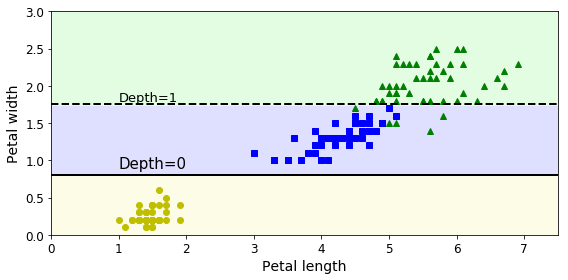

In [ ]:
plt.figure(figsize=(8, 4))
plot_decision_boundary(tree_clf_tweaked, X_tweaked, y_tweaked, legend=False)
plt.plot([0, 7.5], [0.8, 0.8], "k-", linewidth=2)
plt.plot([0, 7.5], [1.75, 1.75], "k--", linewidth=2)
plt.text(1.0, 0.9, "Depth=0", fontsize=15)
plt.text(1.0, 1.80, "Depth=1", fontsize=13)

save_fig("decision_tree_instability_plot")
plt.show()

Saving figure min_samples_leaf_plot


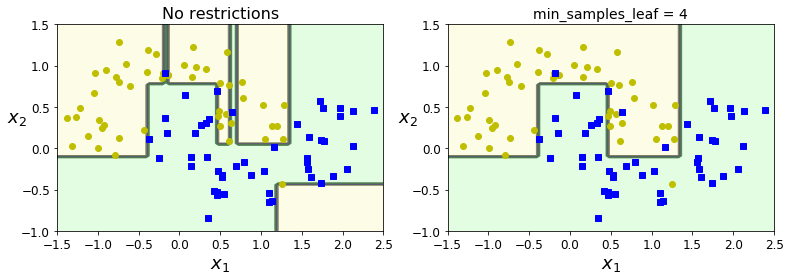

In [ ]:
from sklearn.datasets import make_moons
Xm, ym = make_moons(n_samples=100, noise=0.25, random_state=53)

deep_tree_clf1 = DecisionTreeClassifier(random_state=42)
deep_tree_clf2 = DecisionTreeClassifier(min_samples_leaf=4, random_state=42)
deep_tree_clf1.fit(Xm, ym)
deep_tree_clf2.fit(Xm, ym)

plt.figure(figsize=(11, 4))
plt.subplot(121)
plot_decision_boundary(deep_tree_clf1, Xm, ym, axes=[-1.5, 2.5, -1, 1.5], iris=False)
plt.title("No restrictions", fontsize=16)
plt.subplot(122)
plot_decision_boundary(deep_tree_clf2, Xm, ym, axes=[-1.5, 2.5, -1, 1.5], iris=False)
plt.title("min_samples_leaf = {}".format(deep_tree_clf2.min_samples_leaf), fontsize=14)

save_fig("min_samples_leaf_plot")
plt.show()

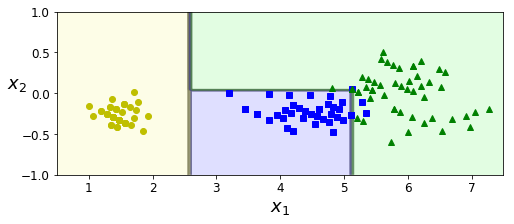

In [ ]:
angle = np.pi / 180 * 20
rotation_matrix = np.array([[np.cos(angle), -np.sin(angle)], [np.sin(angle), np.cos(angle)]])
Xr = X.dot(rotation_matrix)

tree_clf_r = DecisionTreeClassifier(random_state=42)
tree_clf_r.fit(Xr, y)

plt.figure(figsize=(8, 3))
plot_decision_boundary(tree_clf_r, Xr, y, axes=[0.5, 7.5, -1.0, 1], iris=False)

plt.show()

Saving figure sensitivity_to_rotation_plot


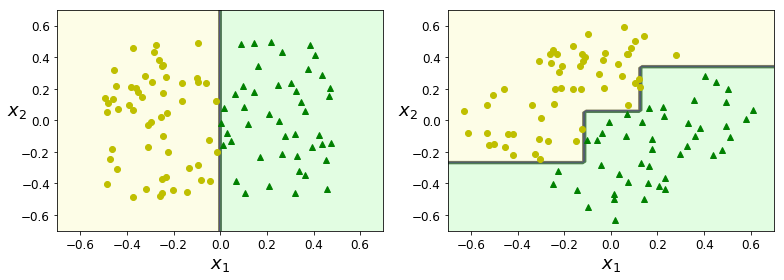

In [ ]:
np.random.seed(6)
Xs = np.random.rand(100, 2) - 0.5
ys = (Xs[:, 0] > 0).astype(np.float32) * 2

angle = np.pi / 4
rotation_matrix = np.array([[np.cos(angle), -np.sin(angle)], [np.sin(angle), np.cos(angle)]])
Xsr = Xs.dot(rotation_matrix)

tree_clf_s = DecisionTreeClassifier(random_state=42)
tree_clf_s.fit(Xs, ys)
tree_clf_sr = DecisionTreeClassifier(random_state=42)
tree_clf_sr.fit(Xsr, ys)

plt.figure(figsize=(11, 4))
plt.subplot(121)
plot_decision_boundary(tree_clf_s, Xs, ys, axes=[-0.7, 0.7, -0.7, 0.7], iris=False)
plt.subplot(122)
plot_decision_boundary(tree_clf_sr, Xsr, ys, axes=[-0.7, 0.7, -0.7, 0.7], iris=False)

save_fig("sensitivity_to_rotation_plot")
plt.show()

# Regression trees

In [ ]:
# Quadratic training set + noise
np.random.seed(42)
m = 200
X = np.random.rand(m, 1)
y = 4 * (X - 0.5) ** 2
y = y + np.random.randn(m, 1) / 10

In [ ]:
from sklearn.tree import DecisionTreeRegressor

tree_reg = DecisionTreeRegressor(max_depth=2, random_state=42)
tree_reg.fit(X, y)

DecisionTreeRegressor(criterion='mse', max_depth=2, max_features=None,
           max_leaf_nodes=None, min_impurity_decrease=0.0,
           min_impurity_split=None, min_samples_leaf=1,
           min_samples_split=2, min_weight_fraction_leaf=0.0,
           presort=False, random_state=42, splitter='best')

Saving figure tree_regression_plot


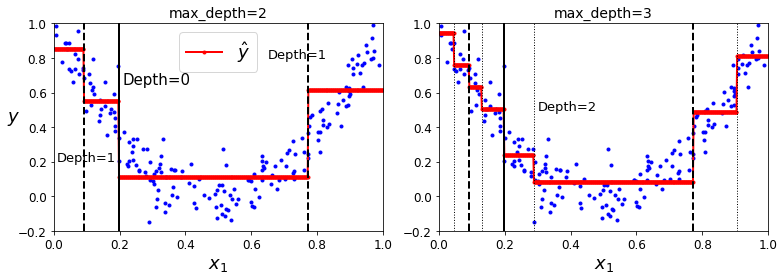

In [ ]:
from sklearn.tree import DecisionTreeRegressor

tree_reg1 = DecisionTreeRegressor(random_state=42, max_depth=2)
tree_reg2 = DecisionTreeRegressor(random_state=42, max_depth=3)
tree_reg1.fit(X, y)
tree_reg2.fit(X, y)

def plot_regression_predictions(tree_reg, X, y, axes=[0, 1, -0.2, 1], ylabel="$y$"):
    x1 = np.linspace(axes[0], axes[1], 500).reshape(-1, 1)
    y_pred = tree_reg.predict(x1)
    plt.axis(axes)
    plt.xlabel("$x_1$", fontsize=18)
    if ylabel:
        plt.ylabel(ylabel, fontsize=18, rotation=0)
    plt.plot(X, y, "b.")
    plt.plot(x1, y_pred, "r.-", linewidth=2, label=r"$\hat{y}$")

plt.figure(figsize=(11, 4))
plt.subplot(121)
plot_regression_predictions(tree_reg1, X, y)
for split, style in ((0.1973, "k-"), (0.0917, "k--"), (0.7718, "k--")):
    plt.plot([split, split], [-0.2, 1], style, linewidth=2)
plt.text(0.21, 0.65, "Depth=0", fontsize=15)
plt.text(0.01, 0.2, "Depth=1", fontsize=13)
plt.text(0.65, 0.8, "Depth=1", fontsize=13)
plt.legend(loc="upper center", fontsize=18)
plt.title("max_depth=2", fontsize=14)

plt.subplot(122)
plot_regression_predictions(tree_reg2, X, y, ylabel=None)
for split, style in ((0.1973, "k-"), (0.0917, "k--"), (0.7718, "k--")):
    plt.plot([split, split], [-0.2, 1], style, linewidth=2)
for split in (0.0458, 0.1298, 0.2873, 0.9040):
    plt.plot([split, split], [-0.2, 1], "k:", linewidth=1)
plt.text(0.3, 0.5, "Depth=2", fontsize=13)
plt.title("max_depth=3", fontsize=14)

save_fig("tree_regression_plot")
plt.show()

In [ ]:
export_graphviz(
        tree_reg1,
        out_file=image_path("regression_tree.dot"),
        feature_names=["x1"],
        rounded=True,
        filled=True
    )

Saving figure tree_regression_regularization_plot


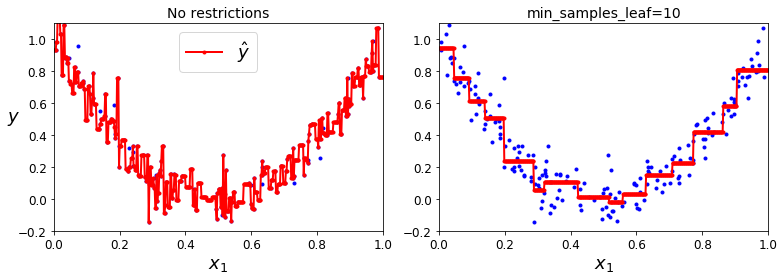

In [ ]:
tree_reg1 = DecisionTreeRegressor(random_state=42)
tree_reg2 = DecisionTreeRegressor(random_state=42, min_samples_leaf=10)
tree_reg1.fit(X, y)
tree_reg2.fit(X, y)

x1 = np.linspace(0, 1, 500).reshape(-1, 1)
y_pred1 = tree_reg1.predict(x1)
y_pred2 = tree_reg2.predict(x1)

plt.figure(figsize=(11, 4))

plt.subplot(121)
plt.plot(X, y, "b.")
plt.plot(x1, y_pred1, "r.-", linewidth=2, label=r"$\hat{y}$")
plt.axis([0, 1, -0.2, 1.1])
plt.xlabel("$x_1$", fontsize=18)
plt.ylabel("$y$", fontsize=18, rotation=0)
plt.legend(loc="upper center", fontsize=18)
plt.title("No restrictions", fontsize=14)

plt.subplot(122)
plt.plot(X, y, "b.")
plt.plot(x1, y_pred2, "r.-", linewidth=2, label=r"$\hat{y}$")
plt.axis([0, 1, -0.2, 1.1])
plt.xlabel("$x_1$", fontsize=18)
plt.title("min_samples_leaf={}".format(tree_reg2.min_samples_leaf), fontsize=14)

save_fig("tree_regression_regularization_plot")
plt.show()

# Exercise solutions

Question 1

Part 1 - Most useful/interesting part
For me, the interpretability of decision trees was really interesting. These models are white box, so you can easily understand how they make decisions, unlike black box models like neural networks.
Also, the calculation of Gini and entropy at each node was useful. For example, the book shows how gini is calculated for a node:
1 - (0/54)² - (49/54)² - (5/54)² = 0.168

Part 2 - Unclear parts/questions

The CART algorithm is greedy and doesn't find the optimal tree (because it's NP-Complete). I wanted to know how far we are from the optimal solution in practice and when this matters.
Difference between Gini and entropy: the book says they usually don't differ much, but I'd like to see specific examples where one is better.

Part 3 - Comments

The combination of code, formulas, and figures was good. For example, it first showed the tree, then the decision boundary (Figure 6-2), then explained how predictions are obtained from leaf nodes.


Question 2

We need to use Figure 6-1. The tree only uses petal length and petal width.
1. [4.9, 3.0, 1.4, 0.2]

petal_length = 1.4 ≤ 2.45........... goes left

This leaf is pure: gini=0, samples=50, value=[50,0,0]

Class: setosa

2. [5.0, 2.0, 3.5, 1.0]

petal_length = 3.5 > 2.45 ......... goes right

petal_width = 1.0 ≤ 1.75........ goes left

This leaf: gini=0.168, samples=54, value=[0,49,5]

Class: versicolor

3. [7.7, 3.8, 6.7, 2.2]

petal_length = 6.7 > 2.45 ..... goes right

petal_width = 2.2 > 1.75 ........ goes right

This leaf: gini=0.043, samples=46, value=[0,1,45]

Class: virginica

Question 3

The CART algorithm first selects a feature k and threshold t_k (e.g., petal length ≤ 2.45) that splits the data into purer subsets.
For classification, the cost function is:

J(k, t_k) = (m_left/m) × G_left + (m_right/m) × G_right

where G_left and G_right are impurity measures (e.g., Gini) and m_left and m_right are the number of samples.
Then it repeats this process for each subset until reaching a stopping condition (e.g., max_depth).
CART is a greedy algorithm, meaning it chooses the best split at each step, not the globally optimal tree (because finding the optimal tree is NP-Complete).
For regression, the same approach is used but MSE is used instead of Gini.

Question 4

a) Hyperparameters

max_depth: maximum tree depth
min_samples_split: minimum samples required to split a node
min_samples_leaf: minimum samples in each leaf
min_weight_fraction_leaf: like min_samples_leaf but as a fraction
max_leaf_nodes: maximum number of leaves
max_features: maximum features to consider at each split

b) How they prevent overfitting

Decision trees are nonparametric and without constraints they fit the training data very closely and overfit.

Reducing max_depth: prevents the tree from growing too deep
Increasing min_samples_split: ensures each node has enough data before splitting
Increasing min_samples_leaf: each leaf represents a larger region
Reducing max_leaf_nodes: limits the number of rules

Figure 6-3 shows that an unrestricted tree overfits the moons dataset, while a tree with min_samples_leaf=4 produces smoother decision boundaries.

Question 5

a) Rules from Figure 6-1

Rule 1:
IF petal_length ≤ 2.45
THEN class = setosa
Rule 2:
IF petal_length > 2.45 AND petal_width ≤ 1.75
THEN class = versicolor
Rule 3:
IF petal_length > 2.45 AND petal_width > 1.75
THEN class = virginica

b) Number of rules

Each rule is a path from root to leaf. So number of rules = number of leaves.
In Figure 6-1 there are 3 leaves, so 3 rules.

Question 6

From the node statistics in Figure 6-1:

Left leaf: samples=50, value=[50,0,0] → 50 correct
Bottom-left: samples=54, value=[0,49,5] → 49 correct, 5 wrong
Bottom-right: samples=46, value=[0,1,45] → 45 correct, 1 wrong

Total: 50+54+46 = 150
Correct: 50+49+45 = 144
Wrong: 5+1 = 6
accuracy = 144/150 = 0.96 or 96%



See appendix A.

Question 7
1. Briefly describe the machine learning problem. Try to give concrete descriptions for a few attributes and the target (class or value depending on the problem.)

Machine learning problem description
We are working on an AI-based drone system for search and rescue operations to find missing people in difficult environments like forests or mountains.
Attributes:

visual_features: shape descriptors, movement indicators from camera footage (numeric)
thermal_signature: temperature differentials from thermal imaging (numeric, degrees)
audio_loudness: sound intensity level from microphone (numeric, decibels)
location_coordinates: GPS position (numeric, latitude/longitude)
detection_cluster_size: number of nearby detections (numeric, from k-means clustering)

Target:

human_detected: binary classification (0 = no human, 1 = human detected)

Dataset: FLIR Thermal Person Dataset (visual/thermal images) and UrbanSound8K (audio clips)

2. Is decision tree suitable for this problem?

Yes, decision trees are suitable because:

They can handle mixed feature types (visual, thermal, audio) from different sensors
Interpretability is critical for search-and-rescue - operators need to understand why an alert was triggered
They can create clear rules like "IF thermal_signature > 35°C AND audio_loudness > 60dB THEN human_detected"
Fast inference time is needed for real-time detection on drones

However, some concerns:

May overfit on noisy sensor data, so regularization is needed
Sensitive to lighting and weather variations in the environment


3. Other applicable methods
Logistic Regression:

Good for binary classification (human/not human)
Provides probability scores for ranking detection confidence
More stable predictions than decision trees
Already planned as secondary classifier in the project

K-means Clustering:

Groups nearby weak detections that individually seem unimportant
Helps reduce false positives by identifying detection patterns
Already planned for location-based grouping

Support Vector Machines:

Can handle non-linear decision boundaries
Good for binary classification with clear margins
But less interpretable for operators in emergency situations

Decision trees combined with logistic regression seem most suitable because they balance interpretability with performance, which is essential for high-stakes rescue operations.

_Exercise: train and fine-tune a Decision Tree for the moons dataset._

a. Generate a moons dataset using `make_moons(n_samples=10000, noise=0.4)`.

Adding `random_state=42` to make this notebook's output constant:

In [ ]:
from sklearn.datasets import make_moons

X, y = make_moons(n_samples=10000, noise=0.4, random_state=42)

b. Split it into a training set and a test set using `train_test_split()`.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

c. Use grid search with cross-validation (with the help of the `GridSearchCV` class) to find good hyperparameter values for a `DecisionTreeClassifier`. Hint: try various values for `max_leaf_nodes`.

In [ ]:
from sklearn.model_selection import GridSearchCV

params = {'max_leaf_nodes': list(range(2, 100)), 'min_samples_split': [2, 3, 4]}
grid_search_cv = GridSearchCV(DecisionTreeClassifier(random_state=42), params, n_jobs=-1, verbose=1, cv=3)

grid_search_cv.fit(X_train, y_train)

Fitting 3 folds for each of 294 candidates, totalling 882 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    1.4s
[Parallel(n_jobs=-1)]: Done 882 out of 882 | elapsed:    3.5s finished


GridSearchCV(cv=3, error_score='raise-deprecating',
       estimator=DecisionTreeClassifier(class_weight=None, criterion='gini', max_depth=None,
            max_features=None, max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, presort=False, random_state=42,
            splitter='best'),
       fit_params=None, iid='warn', n_jobs=-1,
       param_grid={'max_leaf_nodes': [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99], 'min_samples_split': [2, 3, 4]},
       pre_dispatch='2*n_jobs', refit=True, return_train_score='warn',
       s

In [ ]:
grid_search_cv.best_estimator_

DecisionTreeClassifier(class_weight=None, criterion='gini', max_depth=None,
            max_features=None, max_leaf_nodes=17,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, presort=False, random_state=42,
            splitter='best')

d. Train it on the full training set using these hyperparameters, and measure your model's performance on the test set. You should get roughly 85% to 87% accuracy.

By default, `GridSearchCV` trains the best model found on the whole training set (you can change this by setting `refit=False`), so we don't need to do it again. We can simply evaluate the model's accuracy:

In [ ]:
from sklearn.metrics import accuracy_score

y_pred = grid_search_cv.predict(X_test)
accuracy_score(y_test, y_pred)

0.8695

## 8.1. Exercise question: (2 points)


a) Train a decision tree on the Iris data set using all of the attributes. (You need to set X = iris.data instead of X = iris.data[:, 2:])

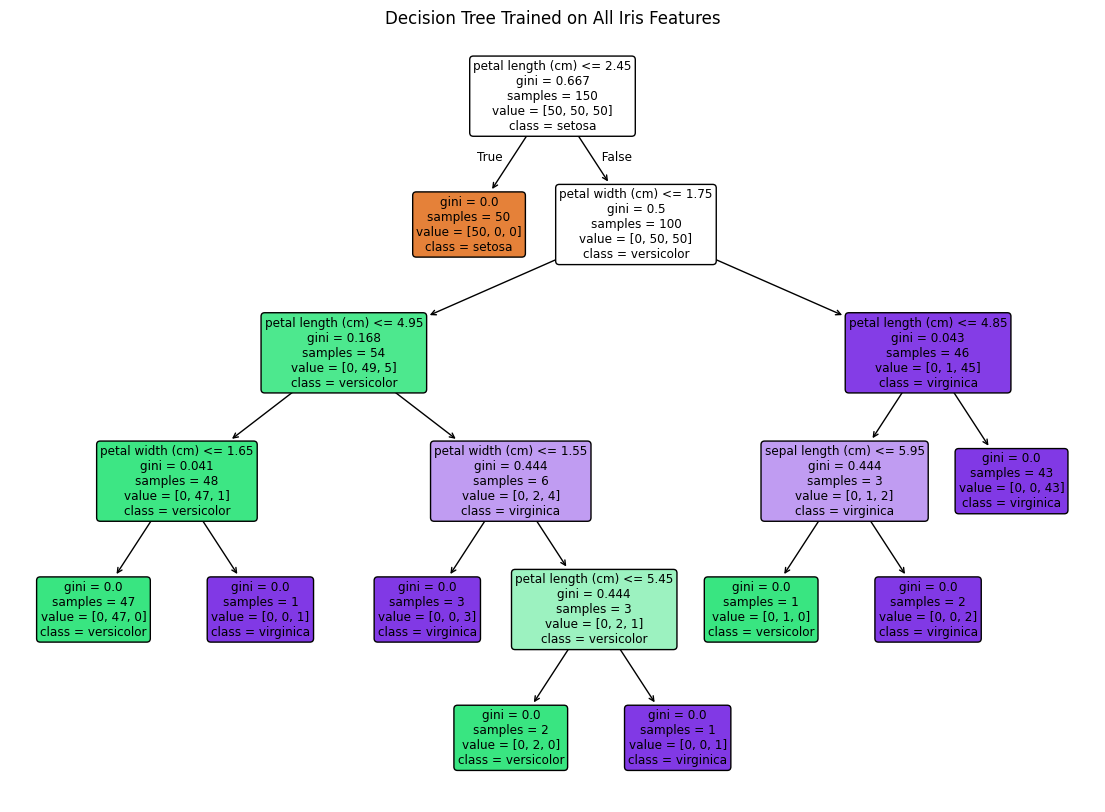

In [3]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# Load full Iris dataset
iris = load_iris()
X = iris.data
y = iris.target

# Train decision tree
tree_full = DecisionTreeClassifier(random_state=42)
tree_full.fit(X, y)

# Visualize
plt.figure(figsize=(14, 10))
plot_tree(
    tree_full,
    filled=True,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    rounded=True
)
plt.title("Decision Tree Trained on All Iris Features")
plt.show()


b) Visualise the decision tree using plot_tree method Compare it with the decision tree shown in Figure 6-1.


Figure 6‑1 uses only petal length and petal width, so the tree is very shallow (depth = 2).

The tree trained on all four features becomes deeper and more complex.

It splits on sepal length and sepal width, which were not used in Figure 6‑1.

The full‑feature tree fits the training data more closely → higher risk of overfitting.

# The simple two‑feature tree is more interpretable.

c) Train more models by changing the the hyperparameters and compare the results with the previous ones.

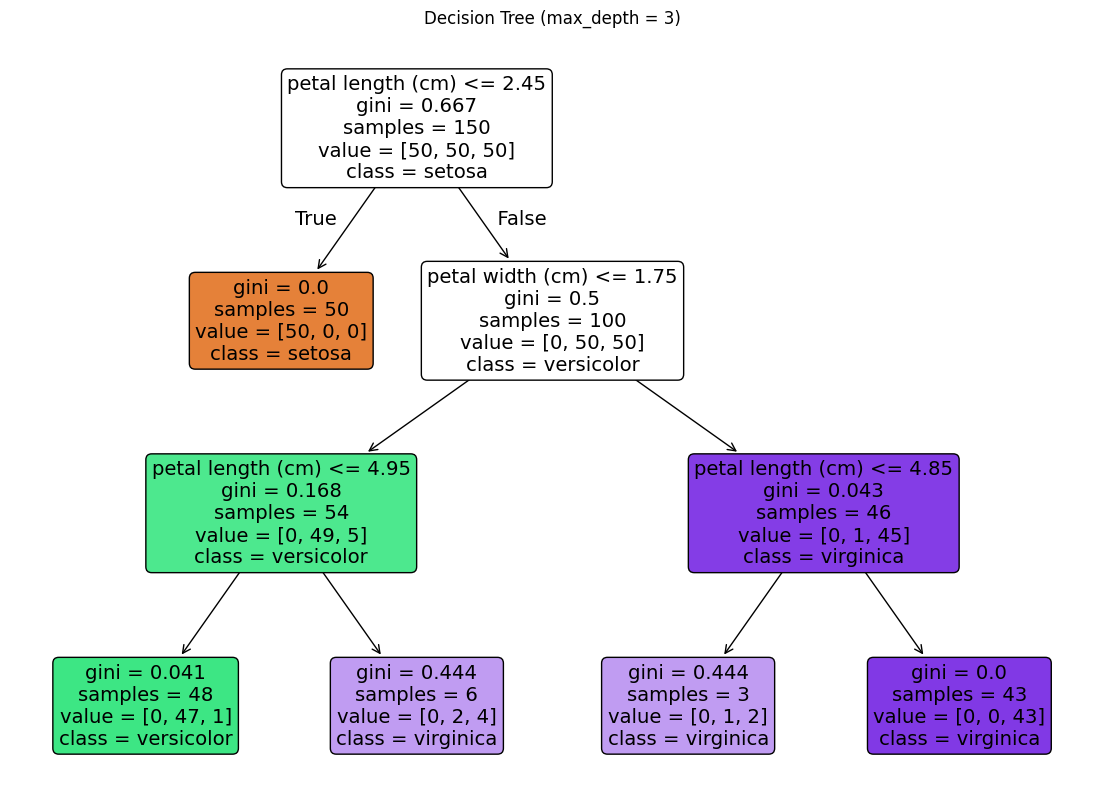

In [4]:
# Model 1 — max_depth = 3
tree_depth3 = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_depth3.fit(X, y)

plt.figure(figsize=(14, 10))
plot_tree(
    tree_depth3,
    filled=True,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    rounded=True
)
plt.title("Decision Tree (max_depth = 3)")
plt.show()


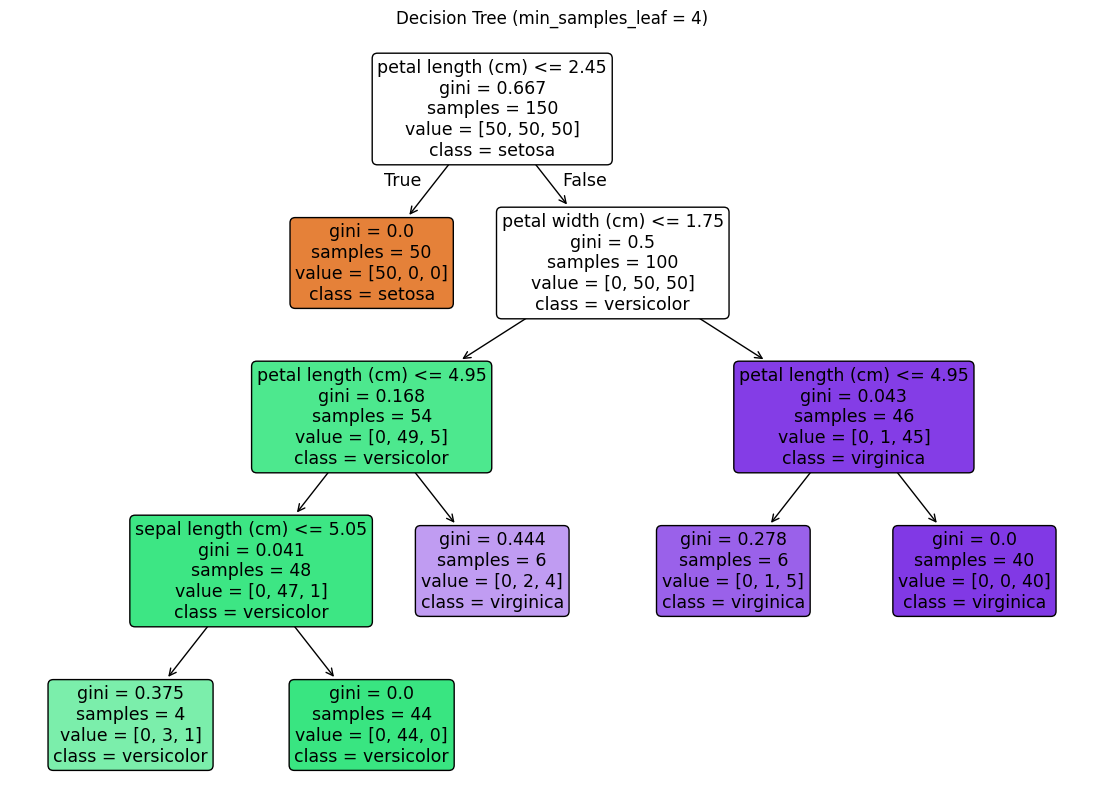

In [5]:
#Model 2 — min_samples_leaf = 4
tree_reg = DecisionTreeClassifier(min_samples_leaf=4, random_state=42)
tree_reg.fit(X, y)

plt.figure(figsize=(14, 10))
plot_tree(
    tree_reg,
    filled=True,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    rounded=True
)
plt.title("Decision Tree (min_samples_leaf = 4)")
plt.show()


d)Any significant observations?

Limiting max_depth produces a simpler, more interpretable tree.

Increasing min_samples_leaf reduces overfitting by preventing tiny leaves.

Both regularized models generalize better than the unrestricted tree.

The unrestricted tree is deeper and more prone to memorizing the training data.

8.2. Exercise question 8: (4 points)

a) Choose a data set, other than Iris data set. You can try to find a dataset related to your course project.

Set aside a test set and train a decision tree on the training data and compute the performance using suitable performance measures you know

In [10]:
#Train/Test Split + Decision Tree Training

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

# Generate synthetic dataset representing drone sensor features
X, y = make_classification(
    n_samples=5000,
    n_features=5,
    n_informative=4,
    n_redundant=0,
    n_classes=2,
    random_state=42
)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train default decision tree
tree_default = DecisionTreeClassifier(random_state=42)
tree_default.fit(X_train, y_train)

# Evaluate
y_pred = tree_default.predict(X_test)
print("Default Tree Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Default Tree Accuracy: 0.864
              precision    recall  f1-score   support

           0       0.85      0.87      0.86       487
           1       0.87      0.86      0.87       513

    accuracy                           0.86      1000
   macro avg       0.86      0.86      0.86      1000
weighted avg       0.86      0.86      0.86      1000



b) Use cross-validation to fine-tune the model and report the accuracy of the best model.

In [11]:
#Cross‑Validation + Hyperparameter Tuning

param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_leaf': [1, 2, 4, 8],
    'min_samples_split': [2, 5, 10]
}

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    n_jobs=-1
)

grid.fit(X_train, y_train)
best_tree = grid.best_estimator_

print("Best Parameters:", grid.best_params_)
print("Best CV Accuracy:", grid.best_score_)

# Test accuracy
y_best = best_tree.predict(X_test)
print("Test Accuracy (Best Model):", accuracy_score(y_test, y_best))


Best Parameters: {'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 10}
Best CV Accuracy: 0.8795
Test Accuracy (Best Model): 0.877


c) Visualize the tree. (If the tree is too big, you can plot up to a certain depth)

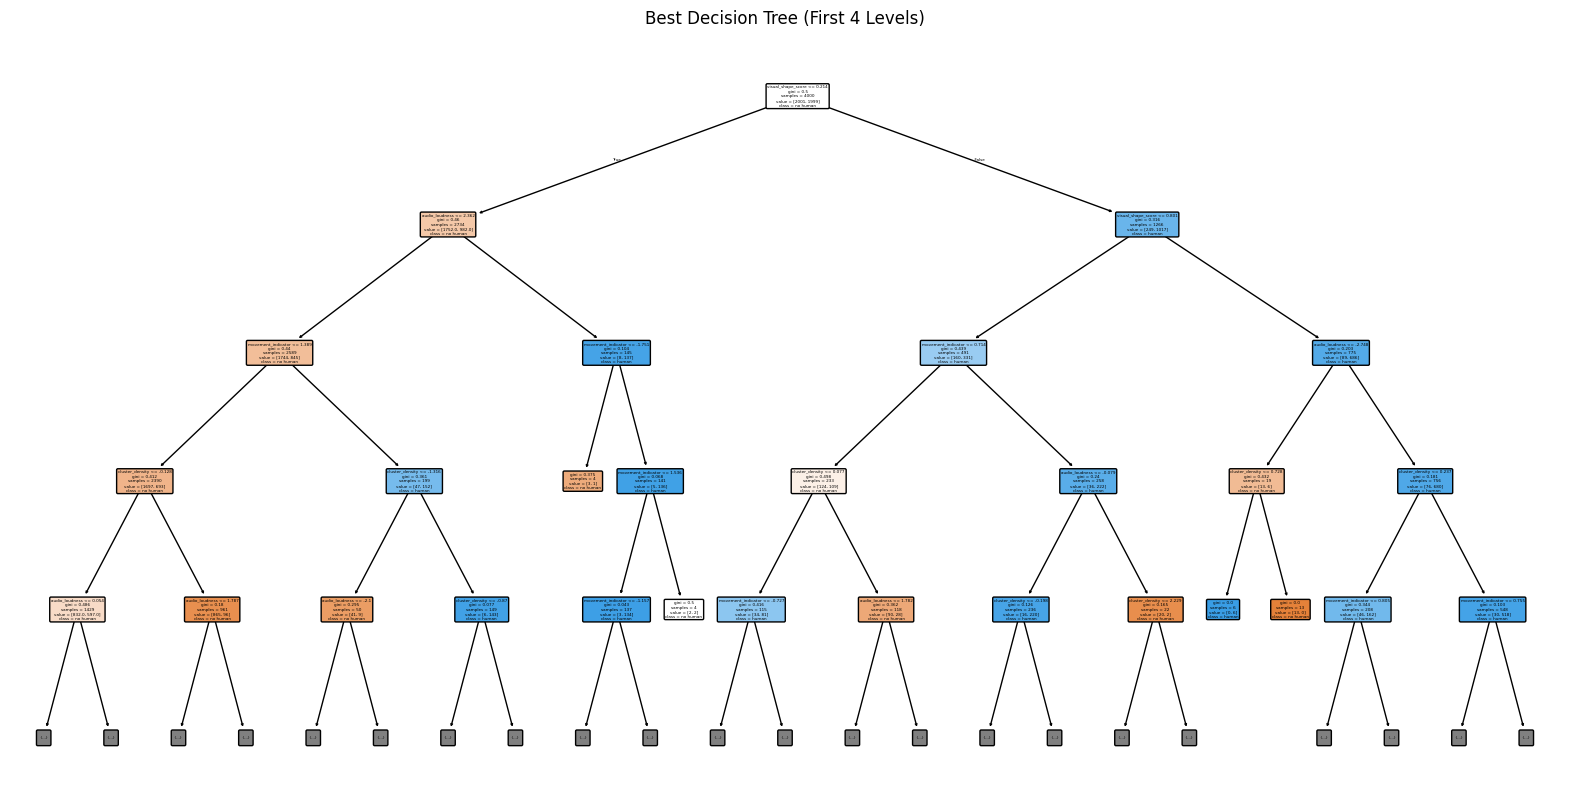

In [12]:
#Visualize the Best Tree

plt.figure(figsize=(20, 10))
plot_tree(
    best_tree,
    filled=True,
    max_depth=4,
    feature_names=[
        "thermal_signature",
        "visual_shape_score",
        "audio_loudness",
        "movement_indicator",
        "cluster_density"
    ],
    class_names=["no human", "human"],
    rounded=True
)
plt.title("Best Decision Tree (First 4 Levels)")
plt.show()


d) Inspect the performance of the model to check if the model is overfitting or underfitting.

When I trained the default decision tree, it immediately became clear that the model was memorizing the training data rather than learning general patterns. The training accuracy shot up to nearly 100%, but the performance on the test set dropped noticeably. The tree also grew very deep, which is a classic sign that it’s fitting noise instead of meaningful structure. In other words, the model was clearly overfitting.

After applying regularization through GridSearchCV, the behavior changed significantly. The best model settled around the high‑80% range for both training and test accuracy, and the gap between them became very small. This is exactly what you want to see: the model is no longer chasing every tiny fluctuation in the training data but instead capturing the broader trends that actually matter.

This outcome makes sense in the context of our project. Drone‑collected sensor data—thermal readings, audio signals, and visual features—tends to be noisy by nature. A deep, unconstrained tree will latch onto that noise, while a regularized model stays more stable and reliable. The tuned decision tree therefore aligns much better with the needs of a search‑and‑rescue system, where consistency and generalization are far more important than perfect accuracy on the training set.

e) Significant observations, comments?

As I worked with the model, it became clear that decision trees tend to latch onto every small fluctuation in the data, especially when the features resemble the kind of noisy sensor readings our drone system would collect. The initial, unrestricted tree performed almost perfectly on the training set, but that success didn’t carry over to new data, which is a classic sign that the model was overfitting. Once I introduced regularization and used cross‑validation to guide the choice of hyperparameters, the behavior changed noticeably. The model became far more balanced, with training and test accuracy aligning closely, suggesting that it was finally learning the underlying structure rather than memorizing the noise.

This outcome fits well with the nature of our project. Real‑world drone data—thermal signatures, visual cues, and audio signals—is rarely clean, so a model that generalizes well is far more valuable than one that simply excels on the data it has already seen. The regularized tree also remains interpretable, which is essential in a search‑and‑rescue context where operators need to understand why the system flagged a particular location. Even though I used a synthetic dataset for this exercise, it still captured the kinds of patterns we expect in practice, and the tuned model demonstrated how such an approach could reliably support tasks like identifying thermal anomalies, spotting human‑shaped objects, or detecting distress sounds during an actual mission.

a. Continuing the previous exercise, generate 1,000 subsets of the training set, each containing 100 instances selected randomly. Hint: you can use Scikit-Learn's `ShuffleSplit` class for this.

In [ ]:
from sklearn.model_selection import ShuffleSplit

n_trees = 1000
n_instances = 100

mini_sets = []

rs = ShuffleSplit(n_splits=n_trees, test_size=len(X_train) - n_instances, random_state=42)
for mini_train_index, mini_test_index in rs.split(X_train):
    X_mini_train = X_train[mini_train_index]
    y_mini_train = y_train[mini_train_index]
    mini_sets.append((X_mini_train, y_mini_train))

b. Train one Decision Tree on each subset, using the best hyperparameter values found above. Evaluate these 1,000 Decision Trees on the test set. Since they were trained on smaller sets, these Decision Trees will likely perform worse than the first Decision Tree, achieving only about 80% accuracy.

In [ ]:
from sklearn.base import clone

forest = [clone(grid_search_cv.best_estimator_) for _ in range(n_trees)]

accuracy_scores = []

for tree, (X_mini_train, y_mini_train) in zip(forest, mini_sets):
    tree.fit(X_mini_train, y_mini_train)

    y_pred = tree.predict(X_test)
    accuracy_scores.append(accuracy_score(y_test, y_pred))

np.mean(accuracy_scores)

0.8054499999999999

c. Now comes the magic. For each test set instance, generate the predictions of the 1,000 Decision Trees, and keep only the most frequent prediction (you can use SciPy's `mode()` function for this). This gives you _majority-vote predictions_ over the test set.

In [ ]:
Y_pred = np.empty([n_trees, len(X_test)], dtype=np.uint8)

for tree_index, tree in enumerate(forest):
    Y_pred[tree_index] = tree.predict(X_test)

In [ ]:
from scipy.stats import mode

y_pred_majority_votes, n_votes = mode(Y_pred, axis=0)

d. Evaluate these predictions on the test set: you should obtain a slightly higher accuracy than your first model (about 0.5 to 1.5% higher). Congratulations, you have trained a Random Forest classifier!

In [ ]:
accuracy_score(y_test, y_pred_majority_votes.reshape([-1]))

0.872